Loading Pattern B datasets...
Data loading and timestamp alignment complete.
Total missing blackout cells evaluated: 3,480

Generating diagnostics for Volume...


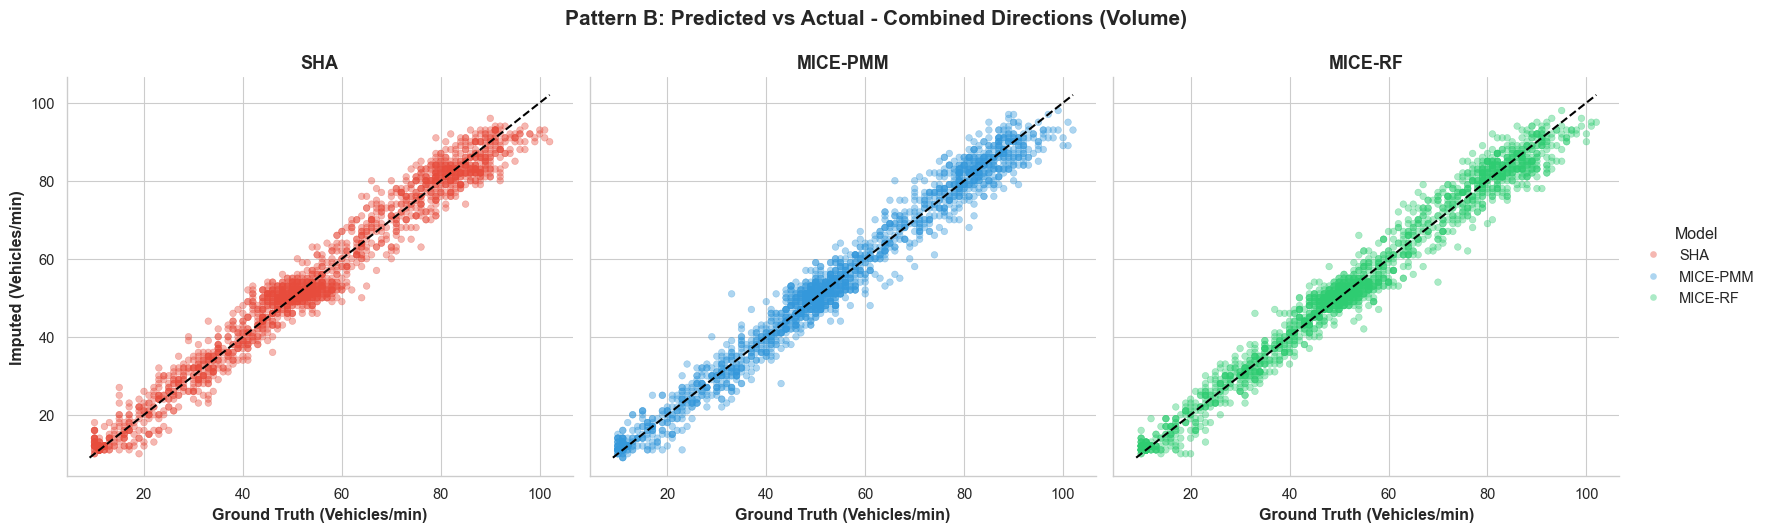

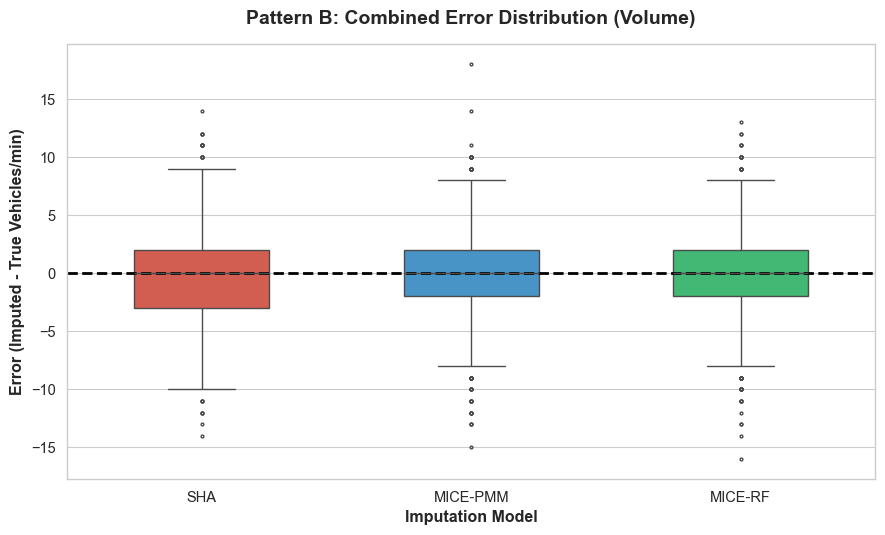

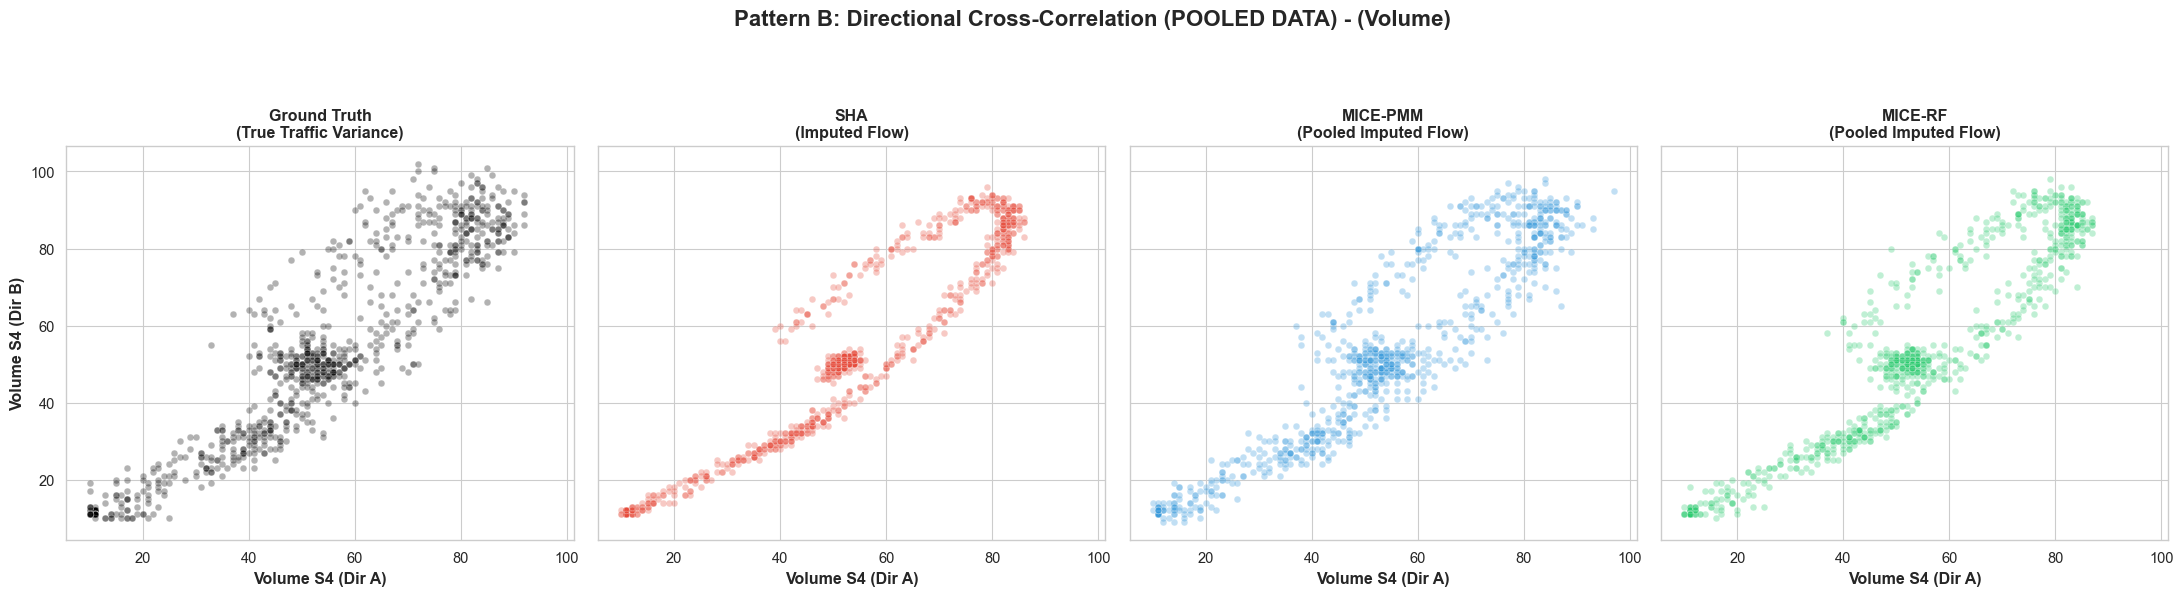

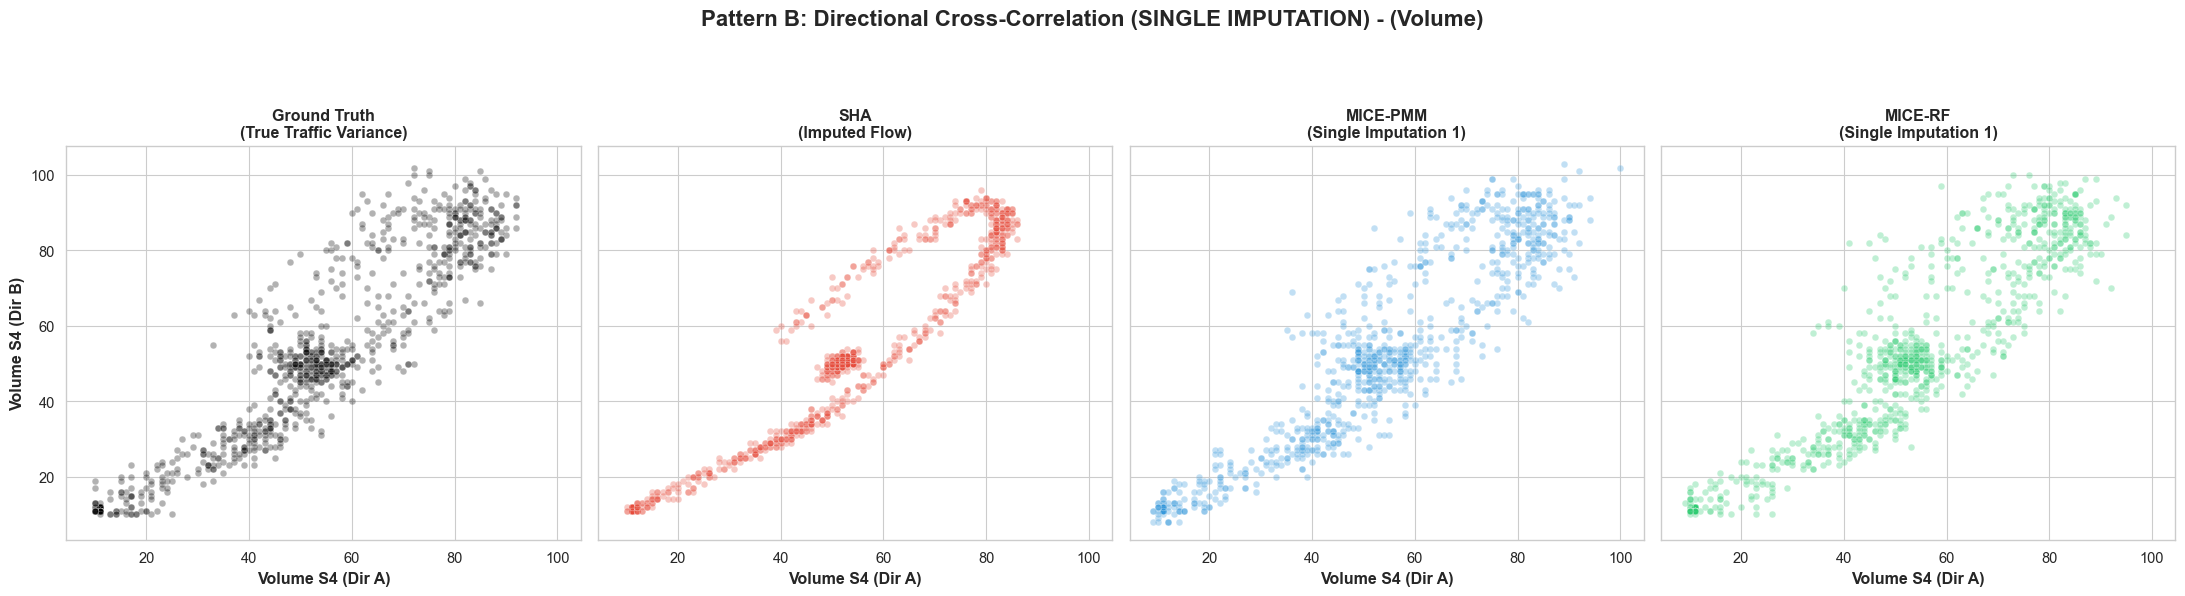


Generating diagnostics for Speed...


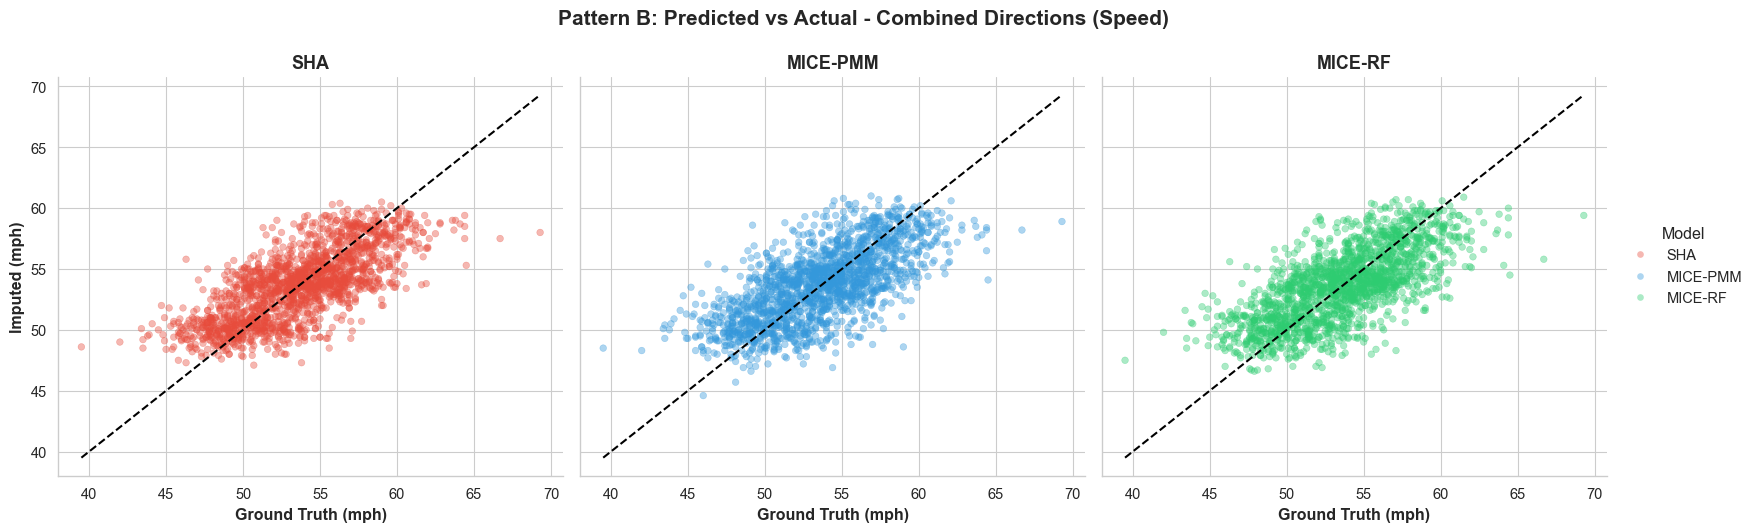

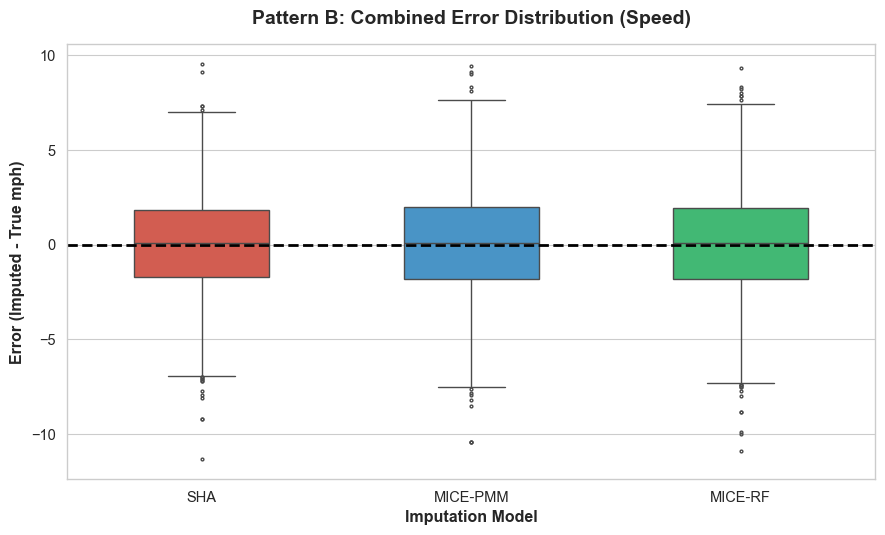

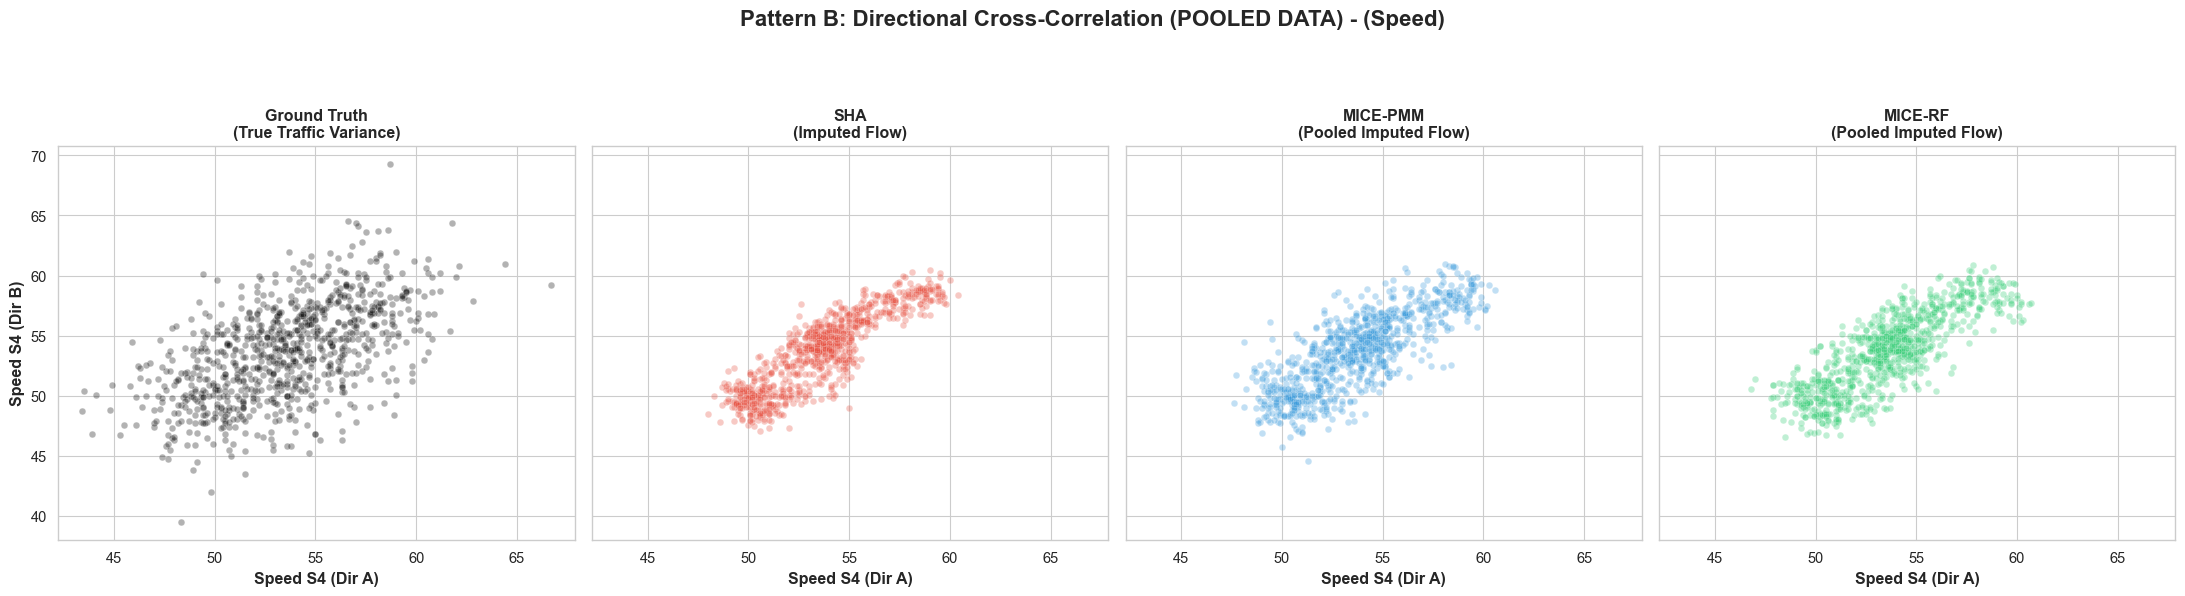

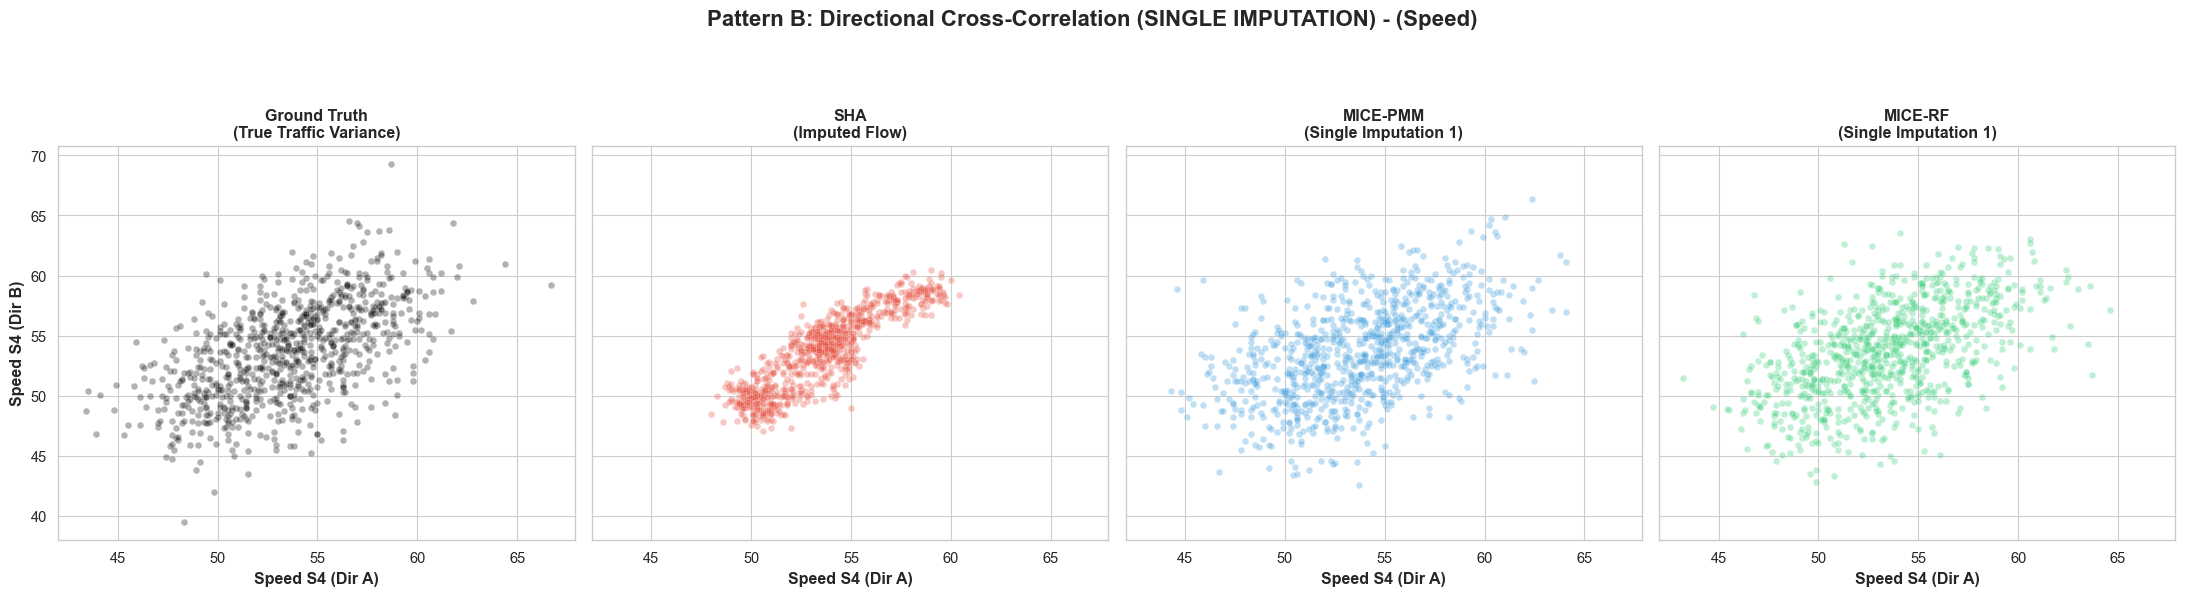


Generating TMT Macroeconomic Plot...


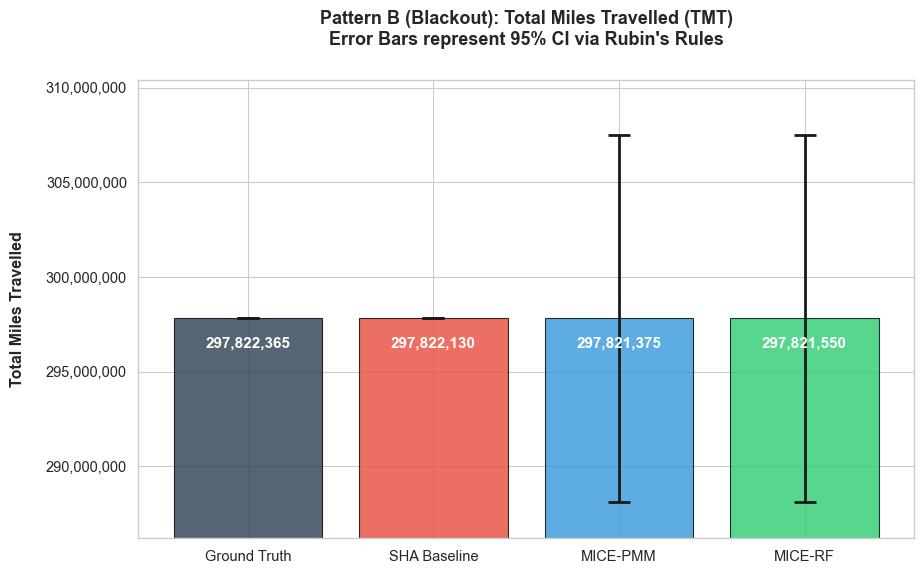


All Pattern B visualizations generated successfully.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings

# 1. GLOBAL SETTINGS 
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
PALETTE = {"SHA": "#e74c3c", "MICE-PMM": "#3498db", "MICE-RF": "#2ecc71"}
TARGET_VARS = ['Vol_S4_dir_a', 'Vol_S4_dir_b', 'Spd_S4_dir_a', 'Spd_S4_dir_b']


# 2. DATA LOADING & PREPROCESSING

def load_and_prep_data():
    """Loads CSVs and perfectly aligns timestamps across all imputed datasets."""
    print("Loading Pattern B datasets...")
    
    truth_df = pd.read_csv('MICE_wide_1jamnew.csv')
    miss_df  = pd.read_csv('patternB_curated_blackouts.csv') 
    
    models = {
        'SHA': pd.read_csv('traffic_wide_SHA_patternB.csv'),
        'MICE-PMM': pd.read_csv('patternB_MICE_PMM_pooled.csv'),
        'MICE-RF': pd.read_csv('patternB_MICE_RF_pooled.csv')
    }

    
    single_imps = {
        'MICE-PMM': pd.read_csv('patternB_MICE_PMM_imp1.csv'),
        'MICE-RF': pd.read_csv('patternB_MICE_RF_imp1.csv')
    } 

    tmt_files = {
        'PMM_TMT': pd.read_csv('patternB_TMT.csv'),
        'RF_TMT': pd.read_csv('patternB_MICE_RF_TMT.csv'),
        'SHA_TMT': pd.read_csv('sha_tmt_results_patternB.csv'),
        'PMM_Rubin': pd.read_csv('patternB_Rubin_TMT.csv'),
        'RF_Rubin': pd.read_csv('patternB_MICE_RF_Rubin_TMT.csv')
    }

    # Timestamp Repair Fix
    truth_df['Timestamp'] = pd.to_datetime(truth_df['Timestamp'])
    miss_df['Timestamp']  = pd.to_datetime(truth_df['Timestamp'])

    for name, df in models.items():
        df['Timestamp'] = truth_df['Timestamp'].copy()
        for col in ['DayOfWeek', 'Hour', 'Minute']:
            if col in truth_df.columns:
                df[col] = truth_df[col].copy()
                
    for name, df in single_imps.items():
        df['Timestamp'] = truth_df['Timestamp'].copy()

    print("Data loading and timestamp alignment complete.")
    
    return truth_df, miss_df, models, single_imps, tmt_files


# 3. DATA WRANGLING FUNCTION

def wrangle_comparison_data(truth_df, miss_df, models):
    """Melts datasets, isolates missing blackout cells, and handles SHA zeroes."""
    truth_melt = truth_df.melt(id_vars=['Timestamp'], value_vars=TARGET_VARS, var_name='Variable', value_name='Truth')
    miss_melt = miss_df.melt(id_vars=['Timestamp'], value_vars=TARGET_VARS, var_name='Variable', value_name='Missing')

    # Find exactly where the missing cells are
    master_df = truth_melt.merge(miss_melt, on=['Timestamp', 'Variable'])
    mask = master_df['Missing'].isna() & master_df['Truth'].notna()
    
    missing_cases = master_df[mask].copy()
    missing_cases['Hour'] = missing_cases['Timestamp'].dt.hour
    missing_cases['Metric'] = missing_cases['Variable'].apply(lambda x: 'Volume' if 'Vol' in x else 'Speed')

    plot_data = []
    for model_name, imp_df in models.items():
        imp_melt = imp_df.melt(id_vars=['Timestamp'], value_vars=TARGET_VARS, var_name='Variable', value_name='Imputed')
        
        merged = missing_cases.merge(imp_melt, on=['Timestamp', 'Variable'])
        merged['Error'] = merged['Imputed'] - merged['Truth']
        merged['Abs_Error'] = merged['Error'].abs()
        merged['Model'] = model_name
        
        # Prevent artificial zeroes from ruining the boxplots
        if model_name == 'SHA':
            sha_valid = (merged['Imputed'] != 0) & (merged['Imputed'].notna())
            merged = merged[sha_valid]
            
        plot_data.append(merged)

    comparison_df = pd.concat(plot_data, ignore_index=True)
    return comparison_df, missing_cases


# 4. PLOTTING FUNCTIONS

def plot_scatter(df_subset, metric_type, unit):
    g = sns.relplot(
        data=df_subset, x='Truth', y='Imputed', 
        col='Model', hue='Model', palette=PALETTE, 
        alpha=0.4, height=5, aspect=1.1, edgecolor=None
    )
    
    max_val = df_subset[['Truth', 'Imputed']].max().max()
    min_val = df_subset[['Truth', 'Imputed']].min().min()
    
    for ax in g.axes.flat:
        ax.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--', linewidth=1.5)
        ax.set_title(ax.get_title().replace("Model = ", ""), fontweight='bold', fontsize=13)

    g.set_axis_labels(f"Ground Truth ({unit})", f"Imputed ({unit})", fontweight='bold')
    g.fig.suptitle(f"Pattern B: Predicted vs Actual - Combined Directions ({metric_type})", y=1.06, fontweight='bold', fontsize=15)
    plt.show()

def plot_error_boxplot(df_subset, metric_type, unit):
    plt.figure(figsize=(9, 5.5))
    ax = sns.boxplot(
        x="Model", y="Error", data=df_subset, hue="Model",
        palette=PALETTE, fliersize=2, width=0.5, legend=False
    )
    ax.axhline(0, color='black', linestyle='--', linewidth=2) 
    
    ax.set_title(f"Pattern B: Combined Error Distribution ({metric_type})", fontweight='bold', fontsize=14, pad=15)
    ax.set_ylabel(f"Error (Imputed - True {unit})", fontweight='bold')
    ax.set_xlabel("Imputation Model", fontweight='bold')
    
    plt.tight_layout()
    plt.show()

def plot_cross_correlation(truth_df, models, blackout_timestamps, metric, var_a, var_b):
    truth_sub = truth_df[truth_df['Timestamp'].isin(blackout_timestamps)].set_index('Timestamp')
    sha_sub   = models['SHA'][models['SHA']['Timestamp'].isin(blackout_timestamps)].set_index('Timestamp')
    pmm_sub   = models['MICE-PMM'][models['MICE-PMM']['Timestamp'].isin(blackout_timestamps)].set_index('Timestamp')
    rf_sub    = models['MICE-RF'][models['MICE-RF']['Timestamp'].isin(blackout_timestamps)].set_index('Timestamp')

    fig, axes = plt.subplots(1, 4, figsize=(22, 5.5), sharex=True, sharey=True)

    sns.scatterplot(x=truth_sub[var_a], y=truth_sub[var_b], color="black", alpha=0.3, ax=axes[0])
    axes[0].set_title("Ground Truth\n(True Traffic Variance)", fontweight='bold')

    sns.scatterplot(x=sha_sub[var_a], y=sha_sub[var_b], color="#e74c3c", alpha=0.3, ax=axes[1])
    axes[1].set_title("SHA\n(Imputed Flow)", fontweight='bold')

    sns.scatterplot(x=pmm_sub[var_a], y=pmm_sub[var_b], color="#3498db", alpha=0.3, ax=axes[2])
    axes[2].set_title("MICE-PMM\n(Pooled Imputed Flow)", fontweight='bold')

    sns.scatterplot(x=rf_sub[var_a], y=rf_sub[var_b], color="#2ecc71", alpha=0.3, ax=axes[3])
    axes[3].set_title("MICE-RF\n(Pooled Imputed Flow)", fontweight='bold')

    for ax in axes:
        ax.set_xlabel(f"{metric} S4 (Dir A)", fontweight='bold')
        ax.set_ylabel(f"{metric} S4 (Dir B)", fontweight='bold')

    plt.suptitle(f"Pattern B: Directional Cross-Correlation (POOLED DATA) - ({metric})", fontweight='bold', fontsize=16, y=1.08)
    plt.tight_layout()
    plt.show()

def plot_cross_correlation_single_imp(truth_df, models, single_imps, blackout_timestamps, metric, var_a, var_b):
    """Plots the SINGLE IMPUTATION datasets."""
    truth_sub = truth_df[truth_df['Timestamp'].isin(blackout_timestamps)].set_index('Timestamp')
    sha_sub   = models['SHA'][models['SHA']['Timestamp'].isin(blackout_timestamps)].set_index('Timestamp')
    
    pmm_sub   = single_imps['MICE-PMM'][single_imps['MICE-PMM']['Timestamp'].isin(blackout_timestamps)].set_index('Timestamp')
    rf_sub    = single_imps['MICE-RF'][single_imps['MICE-RF']['Timestamp'].isin(blackout_timestamps)].set_index('Timestamp')

    fig, axes = plt.subplots(1, 4, figsize=(22, 5.5), sharex=True, sharey=True)

    sns.scatterplot(x=truth_sub[var_a], y=truth_sub[var_b], color="black", alpha=0.3, ax=axes[0])
    axes[0].set_title("Ground Truth\n(True Traffic Variance)", fontweight='bold')

    sns.scatterplot(x=sha_sub[var_a], y=sha_sub[var_b], color="#e74c3c", alpha=0.3, ax=axes[1])
    axes[1].set_title("SHA\n(Imputed Flow)", fontweight='bold')

    sns.scatterplot(x=pmm_sub[var_a], y=pmm_sub[var_b], color="#3498db", alpha=0.3, ax=axes[2])
    axes[2].set_title("MICE-PMM\n(Single Imputation 1)", fontweight='bold')

    sns.scatterplot(x=rf_sub[var_a], y=rf_sub[var_b], color="#2ecc71", alpha=0.3, ax=axes[3])
    axes[3].set_title("MICE-RF\n(Single Imputation 1)", fontweight='bold')

    for ax in axes:
        ax.set_xlabel(f"{metric} S4 (Dir A)", fontweight='bold')
        ax.set_ylabel(f"{metric} S4 (Dir B)", fontweight='bold')

    plt.suptitle(f"Pattern B: Directional Cross-Correlation (SINGLE IMPUTATION) - ({metric})", fontweight='bold', fontsize=16, y=1.08)
    plt.tight_layout()
    plt.show()

def plot_tmt_hero(tmt_files):
    tmt_rf  = tmt_files['RF_TMT']
    tmt_pmm = tmt_files['PMM_TMT']
    sha_tmt = tmt_files['SHA_TMT']

    tmt_true = tmt_rf.loc[tmt_rf['Dataset'] == 'GroundTruth', 'TMT'].values[0]
    tmt_sha  = sha_tmt.loc[sha_tmt['Dataset'] == 'SHA_Imputed', 'Total_Miles_Travelled'].values[0]
    tmt_pmm_val = tmt_pmm.loc[tmt_pmm['Dataset'] == 'MICE_PMM_pooled', 'TMT'].values[0]
    tmt_rf_val  = tmt_rf.loc[tmt_rf['Dataset'] == 'MICE_RF_pooled', 'TMT'].values[0]

    se_pmm = tmt_files['PMM_Rubin']['Total_SE'].values[0]
    se_rf  = tmt_files['RF_Rubin']['Total_SE'].values[0]

    fig, ax = plt.subplots(figsize=(10, 6.5)) 
    labels = ['Ground Truth', 'SHA Baseline', 'MICE-PMM', 'MICE-RF']
    values = [tmt_true, tmt_sha, tmt_pmm_val, tmt_rf_val]
    errors = [0, 0, se_pmm * 1.96, se_rf * 1.96] 
    colors = ["#2c3e50", "#e74c3c", "#3498db", "#2ecc71"] 

    bars = ax.bar(labels, values, yerr=errors, capsize=8, color=colors, alpha=0.8, 
                  edgecolor='black', error_kw=dict(lw=2, capthick=2))

    # Calculate absolute bounds considering error bars
    max_reach = max([val + err for val, err in zip(values, errors)])
    min_reach = min([val - err for val, err in zip(values, errors)])
    total_span = max_reach - min_reach

    # Set limits with 10% padding top and bottom
    ax.set_ylim(min_reach - (total_span * 0.10), max_reach + (total_span * 0.15))

    # Position values clearly inside the bars
    v_range = max(values) - min(values)
    for bar in bars:
        yval = bar.get_height()
        # Offset label slightly below the bar height
        inside_y_position = yval - (total_span * 0.05)
        ax.text(bar.get_x() + bar.get_width()/2, inside_y_position, 
                f'{int(yval):,}', ha='center', va='top', color='white', fontweight='bold', fontsize=11)

    ax.set_title("Pattern B (Blackout): Total Miles Travelled (TMT)\nError Bars represent 95% CI via Rubin's Rules", 
                 fontweight='bold', pad=25, fontsize=13)
    ax.set_ylabel("Total Miles Travelled", fontweight='bold', labelpad=15)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
    
    plt.tight_layout(pad=3.0)
    plt.show()


# 5. MAIN EXECUTION

if __name__ == "__main__":
    # 1. Load Data
   
    truth_df, miss_df, models, single_imps, tmt_files = load_and_prep_data()

    # 2. Wrangle Data
    comparison_df, missing_cases = wrangle_comparison_data(truth_df, miss_df, models)
    print(f"Total missing blackout cells evaluated: {len(comparison_df) // 3:,}")

    # 3. Generate Diagnostic Plots (Scatter & Boxplots)
    metrics_config = [
        {"type": "Volume", "unit": "Vehicles/min", "var_a": "Vol_S4_dir_a", "var_b": "Vol_S4_dir_b"},
        {"type": "Speed", "unit": "mph", "var_a": "Spd_S4_dir_a", "var_b": "Spd_S4_dir_b"}
    ]

    blackout_timestamps = missing_cases['Timestamp'].unique()

    for config in metrics_config:
        print(f"\nGenerating diagnostics for {config['type']}...")
        df_subset = comparison_df[comparison_df['Metric'] == config['type']]
        
        plot_scatter(df_subset, config['type'], config['unit'])
        plot_error_boxplot(df_subset, config['type'], config['unit'])
        
        # Original plot (pooled)
        plot_cross_correlation(truth_df, models, blackout_timestamps, config['type'], config['var_a'], config['var_b'])
        
    
        plot_cross_correlation_single_imp(truth_df, models, single_imps, blackout_timestamps, config['type'], config['var_a'], config['var_b'])

    # 4. Generate Macro-Economic TMT Plot
    print("\nGenerating TMT Macroeconomic Plot...")
    plot_tmt_hero(tmt_files)
    
    print("\nAll Pattern B visualizations generated successfully.")
    